# Detección de eventos de tenis por audio

Proyecto de aprendizaje automático. Todo se hace con el audio del partido, sin usar el video.

Hay dos modelos que trabajan por frame:
- Modelo 1: clasifica cada frame en hit / serve / background.
- Modelo 2: separa juego (in_play) de descanso (between_points).

Como hop = SR // FPS = 640, cada frame de las anotaciones cae justo en una fila de los MFCC.

## Preparación

In [1]:
# dependencias (correr una vez)
!pip install librosa soundfile matplotlib numpy pandas scikit-learn torch torchvision


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path
from itertools import groupby
import pickle
import subprocess

In [3]:
# parametros generales
FPS        = 25
SR         = 16000
HOP_LENGTH = SR // FPS          # = 640 muestras por frame (1 frame anotado = 1 fila de mfcc)
N_MFCC     = 40

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# agrupo las 11 etiquetas en 3 clases
label_map = {
    'HNR': 'hit',   'HNL': 'hit',
    'HFR': 'hit',   'HFL': 'hit',
    'SNI': 'serve', 'SFI': 'serve',
    'SNF': 'serve', 'SFF': 'serve',
    'SFL': 'serve', 'SNL': 'serve',
    'OTH': 'background',
}

# pares audio / etiquetas
files = [
    {"audio": "videos/V006.wav", "labels": "labels/V006.txt"},
    {"audio": "videos/V007.wav", "labels": "labels/V007.txt"},
    {"audio": "videos/V008.wav", "labels": "labels/V008.txt"},
    {"audio": "videos/V009.wav", "labels": "labels/V009.txt"},
    {"audio": "videos/V010.wav", "labels": "labels/V010.txt"},
]

POINTS_FILE = "labels/points.txt"

print(f"FPS        : {FPS}")
print(f"Sample rate: {SR} Hz")
print(f"Hop length : {HOP_LENGTH} samples (1 frame = 1 MFCC row)")
print(f"N_MFCC     : {N_MFCC}  ->  feature dim = {N_MFCC*3} (mfcc + delta + delta2)")
print(f"Device     : {DEVICE}")

FPS        : 25
Sample rate: 16000 Hz
Hop length : 640 samples (1 frame = 1 MFCC row)
N_MFCC     : 40  ->  feature dim = 120 (mfcc + delta + delta2)
Device     : mps


## Datos para el Modelo 1

In [4]:
# chequeo que las anotaciones caen dentro del wav
# el frame_id es absoluto; con hop = SR/FPS cada frame es una fila de mfcc
for f in files:
    y, sr = librosa.load(f['audio'], sr=SR, mono=True)
    wav_frames = int(len(y) / sr * FPS)

    df = pd.read_csv(f['labels'], sep='\t', names=['frame', 'label'])
    first_frame = df['frame'].min()
    last_frame  = df['frame'].max()

    print(f"{Path(f['audio']).name}")
    print(f"  WAV ends at frame    : {wav_frames}")
    print(f"  Annotations start at : {first_frame} ({first_frame/FPS:.1f}s)")
    print(f"  Annotations end at   : {last_frame}  ({last_frame/FPS:.1f}s)")
    print(f"  Fits inside WAV?     : {last_frame < wav_frames}")
    print()

V006.wav
  WAV ends at frame    : 123875
  Annotations start at : 25481 (1019.2s)
  Annotations end at   : 120404  (4816.2s)
  Fits inside WAV?     : True

V007.wav
  WAV ends at frame    : 136795
  Annotations start at : 14412 (576.5s)
  Annotations end at   : 135460  (5418.4s)
  Fits inside WAV?     : True

V008.wav
  WAV ends at frame    : 80995
  Annotations start at : 1715 (68.6s)
  Annotations end at   : 79452  (3178.1s)
  Fits inside WAV?     : True

V009.wav
  WAV ends at frame    : 406952
  Annotations start at : 5458 (218.3s)
  Annotations end at   : 405145  (16205.8s)
  Fits inside WAV?     : True

V010.wav
  WAV ends at frame    : 109890
  Annotations start at : 12351 (494.0s)
  Annotations end at   : 107408  (4296.3s)
  Fits inside WAV?     : True



In [5]:
# extraccion de features + carga de un par audio/labels
def extract_features(audio_path):
    """carga el wav y devuelve las features por frame (n_frames, 120): mfcc + delta + delta2"""
    y, sr = librosa.load(audio_path, sr=SR, mono=True)
    mfccs  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
    delta  = librosa.feature.delta(mfccs)
    delta2 = librosa.feature.delta(mfccs, order=2)
    features = np.concatenate([mfccs, delta, delta2], axis=0).T   # (n_frames, 120)
    return features


def load_pair(audio_path, label_path):
    """carga un par audio+labels en un dataframe, alineado frame -> vector de features"""
    features = extract_features(audio_path)

    df = pd.read_csv(label_path, sep='\t', names=['frame', 'label'])
    df['mfcc_index'] = df['frame']                      # frame absoluto = fila de mfcc
    df = df[df['mfcc_index'] < len(features)].reset_index(drop=True)
    df['mfcc'] = list(features[df['mfcc_index'].values])
    df['label_grouped'] = df['label'].map(label_map)

    name = Path(audio_path).name
    print(f"{name}: {len(features)} frames, {len(df)} labeled")
    print(f"  Feature shape per frame: {features[0].shape}")
    print(f"  Labels: {df['label_grouped'].value_counts().to_dict()}")
    print()
    return df

In [6]:
# proceso los 5 videos y junto todo
all_dfs = []
for f in files:
    df = load_pair(f['audio'], f['labels'])
    df['source'] = Path(f['audio']).stem
    all_dfs.append(df)

combined = pd.concat(all_dfs, ignore_index=True)

print(f"Total frames : {len(combined):,}")
print("\nDetailed label counts:")
print(combined['label'].value_counts())
print("\nGrouped label counts:")
print(combined['label_grouped'].value_counts())

V006.wav: 123876 frames, 94924 labeled
  Feature shape per frame: (120,)
  Labels: {'background': 82203, 'serve': 6760, 'hit': 5961}

V007.wav: 136796 frames, 121049 labeled
  Feature shape per frame: (120,)
  Labels: {'background': 101127, 'hit': 10699, 'serve': 9223}

V008.wav: 80996 frames, 77738 labeled
  Feature shape per frame: (120,)
  Labels: {'background': 63482, 'serve': 8056, 'hit': 6200}

V009.wav: 406953 frames, 399688 labeled
  Feature shape per frame: (120,)
  Labels: {'background': 326582, 'hit': 42319, 'serve': 30787}

V010.wav: 109891 frames, 95058 labeled
  Feature shape per frame: (120,)
  Labels: {'background': 78186, 'serve': 8487, 'hit': 8385}

Total frames : 788,457

Detailed label counts:
label
OTH    651580
SFI     22811
SNI     20942
HFR     19104
HFL     18587
HNL     18083
HNR     17790
SNF      8662
SFF      8448
SFL      1668
SNL       782
Name: count, dtype: int64

Grouped label counts:
label_grouped
background    651580
hit            73564
serve       

In [7]:
# armo X e y para el modelo 1
X = np.stack(combined['mfcc'].values)          # (n_frames, 120)
y = combined['label_grouped'].values           # (n_frames,)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")

np.save('X.npy', X)
np.save('y.npy', y)
print('Saved X.npy and y.npy')

X shape : (788457, 120)
y shape : (788457,)
Classes : ['background' 'hit' 'serve']
Saved X.npy and y.npy


## Modelo 1 (hit / serve / background)

In [8]:
# balanceo de clases y encode
# el dataset esta muy desbalanceado (~82% fondo)
# bajo el fondo a 2x el total de eventos
tmp = pd.DataFrame({'label': y})
tmp['idx'] = np.arange(len(y))

df_bg     = tmp[tmp['label'] == 'background']
df_events = tmp[tmp['label'] != 'background']

df_bg_down = resample(df_bg, n_samples=len(df_events) * 2, random_state=42)
df_balanced = pd.concat([df_bg_down, df_events]).sample(frac=1, random_state=42)
indices = df_balanced['idx'].values

X_bal = X[indices]
y_bal = y[indices]

print("Balanced label counts:")
print(pd.Series(y_bal).value_counts())

le = LabelEncoder()
y_encoded = le.fit_transform(y_bal)
print(f"\nClasses : {list(le.classes_)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"\nTrain : {X_train.shape}")
print(f"Test  : {X_test.shape}")

Balanced label counts:
background    273754
hit            73564
serve          63313
Name: count, dtype: int64

Classes : ['background', 'hit', 'serve']

Train : (328504, 120)
Test  : (82127, 120)


In [9]:
# tensores para pytorch
# la cnn espera un canal, por eso el unsqueeze -> (n,1,120)
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=64, shuffle=False)

print(f"Input shape per sample: {tuple(X_train_t[0].shape)}")
print(f"Train batches: {len(train_loader)}")
print(f"Test  batches: {len(test_loader)}")

Input shape per sample: (1, 120)
Train batches: 5133
Test  batches: 1284


In [10]:
# misma red para los dos modelos, cambia solo n_classes
class TennisCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(20),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                 # 64 * 20 = 1280
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.conv(x))


model = TennisCNN(n_classes=len(le.classes_))
print(model)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Classes   : {list(le.classes_)}")

TennisCNN(
  (conv): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): AdaptiveAvgPool1d(output_size=20)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1280, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)

Parameters: 170,883
Classes   : ['background', 'hit', 'serve']


In [11]:
# loop de entrenamiento (lo reuso para el modelo 2)
def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3,
                device=DEVICE, log_every=500):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val = 0.0

    print(f"Using device : {device}")
    print(f"Training on  : {len(train_loader.dataset):,} samples")
    print(f"Validating on: {len(val_loader.dataset):,} samples")
    print('-' * 70)

    for epoch in range(epochs):
        # train
        model.train()
        tr_loss, tr_correct, tr_n = 0.0, 0, 0
        for batch_idx, (xb, yb) in enumerate(train_loader):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            tr_loss    += loss.item() * len(xb)
            tr_correct += (out.argmax(1) == yb).sum().item()
            tr_n       += len(xb)
            if (batch_idx + 1) % log_every == 0:
                pct = 100 * (batch_idx + 1) / len(train_loader)
                print(f"  Epoch {epoch+1:02d} [{batch_idx+1:4d}/{len(train_loader)}]"
                      f" ({pct:5.1f}%) batch loss: {loss.item():.4f}")

        # validacion
        model.eval()
        va_loss, va_correct, va_n = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                va_loss    += criterion(out, yb).item() * len(xb)
                va_correct += (out.argmax(1) == yb).sum().item()
                va_n       += len(xb)

        tr_loss /= tr_n; va_loss /= va_n
        tr_acc = tr_correct / tr_n; va_acc = va_correct / va_n
        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss);   history['val_acc'].append(va_acc)

        mark = ''
        if va_acc > best_val:
            best_val = va_acc
            mark = '  <- best'
        print(f"Epoch {epoch+1:02d}/{epochs}  "
              f"train_loss {tr_loss:.4f} acc {tr_acc:.3f}  |  "
              f"val_loss {va_loss:.4f} acc {va_acc:.3f}{mark}")

    print('-' * 70)
    print(f"Best val accuracy: {best_val:.3f}")
    return history


history = train_model(model, train_loader, test_loader, epochs=30, device=DEVICE)

Using device : mps
Training on  : 328,504 samples
Validating on: 82,127 samples
----------------------------------------------------------------------
  Epoch 01 [ 500/5133] (  9.7%) batch loss: 0.6458
  Epoch 01 [1000/5133] ( 19.5%) batch loss: 0.5949
  Epoch 01 [1500/5133] ( 29.2%) batch loss: 0.6364
  Epoch 01 [2000/5133] ( 39.0%) batch loss: 0.6404
  Epoch 01 [2500/5133] ( 48.7%) batch loss: 0.5511
  Epoch 01 [3000/5133] ( 58.4%) batch loss: 0.4329
  Epoch 01 [3500/5133] ( 68.2%) batch loss: 0.5786
  Epoch 01 [4000/5133] ( 77.9%) batch loss: 0.4008
  Epoch 01 [4500/5133] ( 87.7%) batch loss: 0.6739
  Epoch 01 [5000/5133] ( 97.4%) batch loss: 0.4955
Epoch 01/30  train_loss 0.5959 acc 0.744  |  val_loss 0.5455 acc 0.762  <- best
  Epoch 02 [ 500/5133] (  9.7%) batch loss: 0.5832
  Epoch 02 [1000/5133] ( 19.5%) batch loss: 0.6514
  Epoch 02 [1500/5133] ( 29.2%) batch loss: 0.6137
  Epoch 02 [2000/5133] ( 39.0%) batch loss: 0.6449
  Epoch 02 [2500/5133] ( 48.7%) batch loss: 0.5606
  Ep

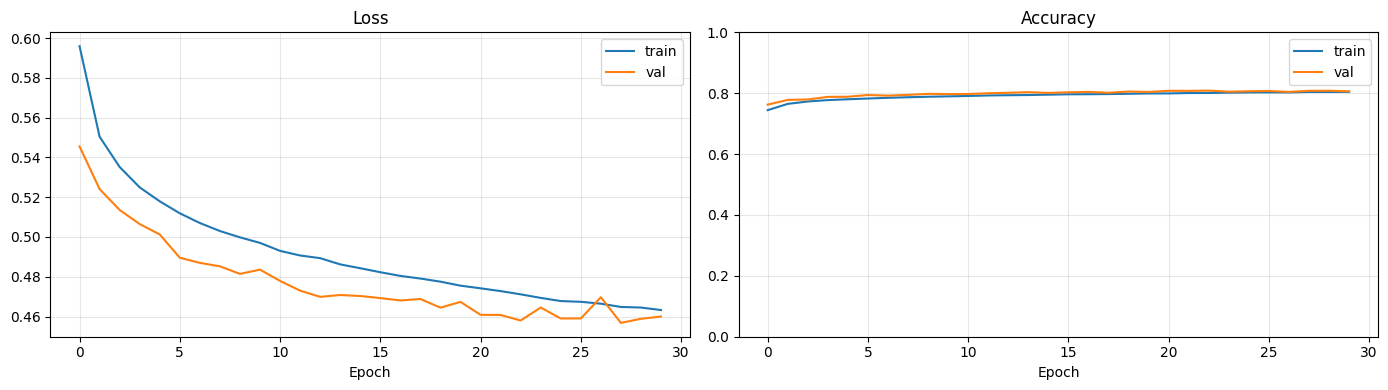

In [12]:
# curvas de loss y accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history['train_loss'], label='train')
ax1.plot(history['val_loss'],   label='val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='train')
ax2.plot(history['val_acc'],   label='val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylim(0, 1)
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

  background       0.85      0.94      0.89     54751
         hit       0.68      0.74      0.71     14713
       serve       0.73      0.31      0.43     12663

    accuracy                           0.81     82127
   macro avg       0.75      0.66      0.68     82127
weighted avg       0.80      0.81      0.79     82127



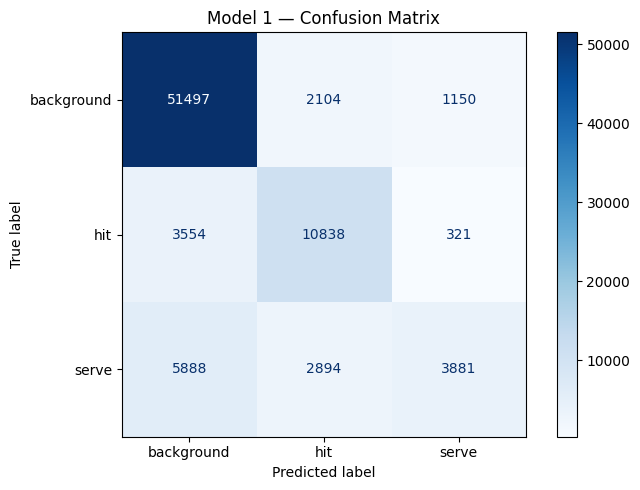

In [13]:
# evaluacion: reporte + matriz de confusion
def evaluate(model, loader, label_encoder, title='Confusion Matrix', device=DEVICE):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds = model(xb).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(yb.numpy())

    print(classification_report(all_true, all_preds, target_names=label_encoder.classes_))

    cm = confusion_matrix(all_true, all_preds)
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_).plot(ax=ax, cmap='Blues')
    plt.title(title); plt.tight_layout(); plt.show()
    return all_true, all_preds


_ = evaluate(model, test_loader, le, title='Model 1 — Confusion Matrix')

In [14]:
# guardo el modelo 1
torch.save({
    'model_state': model.state_dict(),
    'fps'        : FPS,
    'sr'         : SR,
    'hop_length' : HOP_LENGTH,
    'n_mfcc'     : N_MFCC,
    'classes'    : list(le.classes_),
    'label_map'  : label_map,
}, 'tennis_cnn.pt')

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('Saved tennis_cnn.pt and label_encoder.pkl')

Saved tennis_cnn.pt and label_encoder.pkl


## Modelo 2 (detección de puntos)

Clasificador binario por frame: in_play vs between_points, usando las ventanas de points.txt.
Recorto cada video del primer al último punto y balanceo la clase mayoritaria.

In [15]:
# cargo points.txt
points = pd.read_csv(POINTS_FILE, sep='\t',
                     names=['point_id', 'video', 'frame_start', 'frame_end', 'seq'])
points['start_sec']    = points['frame_start'] / FPS
points['end_sec']      = points['frame_end']   / FPS
points['duration_sec'] = points['end_sec'] - points['start_sec']

print(f"Total points: {len(points)}")
print("\nPoints per video:")
print(points['video'].value_counts().sort_index())
print("\nDuration stats (sec):")
print(points['duration_sec'].describe().round(2))

Total points: 746

Points per video:
video
V006     81
V007    129
V008     76
V009    366
V010     94
Name: count, dtype: int64

Duration stats (sec):
count    746.00
mean       8.55
std        4.70
min        2.28
25%        5.25
50%        7.24
75%       10.62
max       36.68
Name: duration_sec, dtype: float64


In [16]:
# dataset del modelo 2 (in_play / between_points), recortado al tramo anotado
def build_model2_dataset(files, points_df):
    X_parts, y_parts = [], []
    for f in files:
        video = Path(f['audio']).stem
        vp = points_df[points_df['video'] == video]
        if len(vp) == 0:
            print(f"{video}: no points, skipped")
            continue

        features = extract_features(f['audio'])          # (n_frames, 120)
        n_frames = len(features)

        first = int(vp['frame_start'].min())
        last  = min(int(vp['frame_end'].max()), n_frames - 1)   # recorto al tramo anotado

        # marco los frames in_play y despues recorto al tramo anotado
        in_play = np.zeros(n_frames, dtype=bool)
        for _, p in vp.iterrows():
            s = int(p['frame_start'])
            e = min(int(p['frame_end']), n_frames - 1)
            in_play[s:e + 1] = True

        span_feats = features[first:last + 1]
        span_mask  = in_play[first:last + 1]
        labels = np.where(span_mask, 'in_play', 'between_points')

        X_parts.append(span_feats)
        y_parts.append(labels)
        print(f"{video}: span [{first}, {last}] -> {len(span_feats)} frames | "
              f"in_play={span_mask.sum()}  between_points={(~span_mask).sum()}")

    X2 = np.concatenate(X_parts, axis=0)
    y2 = np.concatenate(y_parts, axis=0)
    return X2, y2


X2, y2 = build_model2_dataset(files, points)
print(f"\nX2 shape: {X2.shape}")
print(f"Label counts: {pd.Series(y2).value_counts().to_dict()}")

np.save('X2.npy', X2)
np.save('y2.npy', y2)
print('Saved X2.npy and y2.npy')

V006: span [25740, 120012] -> 94273 frames | in_play=15930  between_points=78343
V007: span [14580, 135101] -> 120522 frames | in_play=24402  between_points=96120
V008: span [1864, 79186] -> 77323 frames | in_play=16123  between_points=61200
V009: span [5908, 404460] -> 398553 frames | in_play=83926  between_points=314627
V010: span [12898, 107021] -> 94124 frames | in_play=19863  between_points=74261

X2 shape: (784795, 120)
Label counts: {'between_points': 624551, 'in_play': 160244}
Saved X2.npy and y2.npy


In [17]:
# balanceo, encode y entreno el modelo 2
tmp2 = pd.DataFrame({'label': y2})
tmp2['idx'] = np.arange(len(y2))

counts = tmp2['label'].value_counts()
minority = counts.min()
balanced_parts = [resample(tmp2[tmp2['label'] == lbl], n_samples=minority, random_state=42)
                  for lbl in counts.index]
df2_bal = pd.concat(balanced_parts).sample(frac=1, random_state=42)
idx2 = df2_bal['idx'].values

X2_bal = X2[idx2]
y2_bal = y2[idx2]
print("Balanced label counts:")
print(pd.Series(y2_bal).value_counts())

le2 = LabelEncoder()
y2_encoded = le2.fit_transform(y2_bal)
print(f"\nClasses : {list(le2.classes_)}")

X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2_bal, y2_encoded, test_size=0.2, random_state=42, stratify=y2_encoded
)

X2_tr_t = torch.tensor(X2_tr, dtype=torch.float32).unsqueeze(1)
X2_te_t = torch.tensor(X2_te, dtype=torch.float32).unsqueeze(1)
y2_tr_t = torch.tensor(y2_tr, dtype=torch.long)
y2_te_t = torch.tensor(y2_te, dtype=torch.long)

train_loader2 = DataLoader(TensorDataset(X2_tr_t, y2_tr_t), batch_size=64, shuffle=True)
test_loader2  = DataLoader(TensorDataset(X2_te_t, y2_te_t), batch_size=64, shuffle=False)

model2 = TennisCNN(n_classes=len(le2.classes_))
history2 = train_model(model2, train_loader2, test_loader2, epochs=30, device=DEVICE)

torch.save({
    'model_state': model2.state_dict(),
    'fps'        : FPS,
    'sr'         : SR,
    'hop_length' : HOP_LENGTH,
    'n_mfcc'     : N_MFCC,
    'classes'    : list(le2.classes_),
}, 'tennis_boundary.pt')
with open('label_encoder_boundary.pkl', 'wb') as f:
    pickle.dump(le2, f)
print('Saved tennis_boundary.pt and label_encoder_boundary.pkl')

Balanced label counts:
in_play           160244
between_points    160244
Name: count, dtype: int64

Classes : [np.str_('between_points'), np.str_('in_play')]
Using device : mps
Training on  : 256,390 samples
Validating on: 64,098 samples
----------------------------------------------------------------------
  Epoch 01 [ 500/4007] ( 12.5%) batch loss: 0.4695
  Epoch 01 [1000/4007] ( 25.0%) batch loss: 0.5020
  Epoch 01 [1500/4007] ( 37.4%) batch loss: 0.5990
  Epoch 01 [2000/4007] ( 49.9%) batch loss: 0.4511
  Epoch 01 [2500/4007] ( 62.4%) batch loss: 0.4890
  Epoch 01 [3000/4007] ( 74.9%) batch loss: 0.4963
  Epoch 01 [3500/4007] ( 87.3%) batch loss: 0.4204
  Epoch 01 [4000/4007] ( 99.8%) batch loss: 0.4556
Epoch 01/30  train_loss 0.4846 acc 0.761  |  val_loss 0.4479 acc 0.783  <- best
  Epoch 02 [ 500/4007] ( 12.5%) batch loss: 0.4051
  Epoch 02 [1000/4007] ( 25.0%) batch loss: 0.5997
  Epoch 02 [1500/4007] ( 37.4%) batch loss: 0.3943
  Epoch 02 [2000/4007] ( 49.9%) batch loss: 0.4570

                precision    recall  f1-score   support

between_points       0.83      0.81      0.82     32049
       in_play       0.81      0.83      0.82     32049

      accuracy                           0.82     64098
     macro avg       0.82      0.82      0.82     64098
  weighted avg       0.82      0.82      0.82     64098



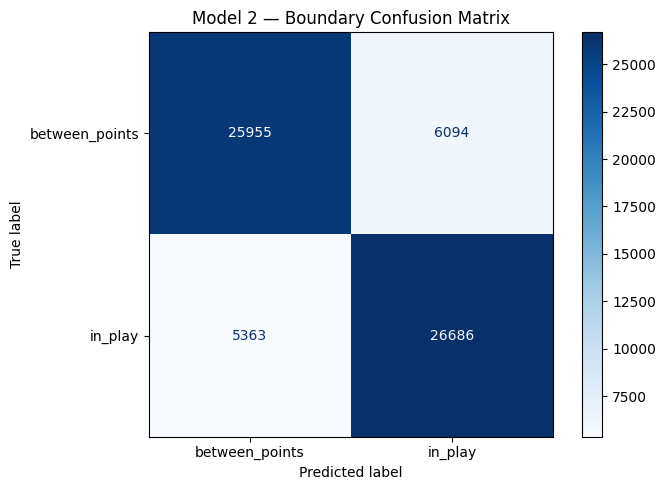

In [18]:
# evaluacion del modelo 2
_ = evaluate(model2, test_loader2, le2, title='Model 2 — Boundary Confusion Matrix')

## Post-procesamiento

In [19]:
# paso de predicciones por frame a eventos con tiempos
def frames_to_events(predictions, fps=25, min_frames=3):
    """agrupa frames seguidos de la misma clase, salta background y filtra los cortos (< min_frames)"""
    events = []
    frame_idx = 0
    for label, group in groupby(predictions):
        length = len(list(group))
        if label != 'background' and length >= min_frames:
            events.append({
                'event'       : label,
                'start_frame' : frame_idx,
                'end_frame'   : frame_idx + length,
                'start_sec'   : round(frame_idx / fps, 2),
                'end_sec'     : round((frame_idx + length) / fps, 2),
                'duration_sec': round(length / fps, 2),
            })
        frame_idx += length
    return pd.DataFrame(events)

In [20]:
# estadisticas del partido a partir de los eventos
def analyze_match(events, fps=25):
    stats = {}
    ev = events.sort_values('start_sec').reset_index(drop=True)

    # un rally = golpes entre dos saques
    rallies, current = [], []
    for _, row in ev.iterrows():
        if row['event'] == 'serve':
            if current:
                rallies.append(current)
            current = []
        elif row['event'] == 'hit':
            current.append(row)
    if current:
        rallies.append(current)

    hits_per_rally = [len(r) for r in rallies]

    # doble falta = dos saques seguidos con < 10s entre medio
    double_faults = 0
    for i in range(len(ev) - 1):
        if ev.loc[i, 'event'] == 'serve' and ev.loc[i + 1, 'event'] == 'serve':
            if ev.loc[i + 1, 'start_sec'] - ev.loc[i, 'end_sec'] < 10:
                double_faults += 1

    n_hits   = int((ev['event'] == 'hit').sum())
    n_serves = int((ev['event'] == 'serve').sum())

    # eventos por minuto
    intensity = {}
    if len(ev) > 0:
        max_min = int(ev['end_sec'].max() / 60) + 1
        for m in range(max_min):
            mask = (ev['start_sec'] >= m * 60) & (ev['start_sec'] < (m + 1) * 60)
            intensity[m] = int(mask.sum())

    stats['total_hits']         = n_hits
    stats['total_serves']       = n_serves
    stats['total_rallies']      = len(rallies)
    stats['double_faults']      = double_faults
    stats['hit_serve_ratio']    = round(n_hits / max(n_serves, 1), 2)
    stats['avg_hits_per_rally'] = round(float(np.mean(hits_per_rally)), 2) if hits_per_rally else 0.0
    stats['max_hits_per_rally'] = int(np.max(hits_per_rally)) if hits_per_rally else 0
    stats['intensity_per_min']  = intensity

    print("=" * 40)
    print("    MATCH STATISTICS")
    print("=" * 40)
    for k, v in stats.items():
        if k != 'intensity_per_min':
            print(f"{k:20s}: {v}")
    print("=" * 40)
    return stats, rallies

In [21]:
# metricas de tiempo dentro y entre rallies
def analyze_temporal_patterns(events, rallies, fps=25):
    ev = events.sort_values('start_sec').reset_index(drop=True)
    serves = ev[ev['event'] == 'serve'].reset_index(drop=True)

    inter_hit_times = []
    for rally in rallies:
        for i in range(len(rally) - 1):
            inter_hit_times.append(rally[i + 1]['start_sec'] - rally[i]['end_sec'])

    rally_durations = [rally[-1]['end_sec'] - rally[0]['start_sec']
                       for rally in rallies if len(rally) > 0]

    rest_times = []
    for rally in rallies:
        if len(rally) > 0:
            last_hit_end = rally[-1]['end_sec']
            nxt = serves[serves['start_sec'] > last_hit_end]
            if len(nxt) > 0:
                rest_times.append(nxt.iloc[0]['start_sec'] - last_hit_end)

    rally_lengths_over_time = [(i, len(r)) for i, r in enumerate(rallies)]

    print("=" * 40)
    print("    TEMPORAL PATTERN ANALYSIS")
    print("=" * 40)
    if inter_hit_times:
        print(f"Avg time between hits : {np.mean(inter_hit_times):.2f}s")
        print(f"Fastest exchange      : {np.min(inter_hit_times):.2f}s")
        print(f"Slowest exchange      : {np.max(inter_hit_times):.2f}s")
    if rally_durations:
        print(f"Avg rally duration    : {np.mean(rally_durations):.2f}s")
        print(f"Longest rally         : {np.max(rally_durations):.2f}s")
    if rest_times:
        print(f"Avg rest between pts  : {np.mean(rest_times):.2f}s")
        print(f"Max rest              : {np.max(rest_times):.2f}s")
    print("=" * 40)

    return {
        'inter_hit_times'        : inter_hit_times,
        'rally_durations'        : rally_durations,
        'rest_times'             : rest_times,
        'rally_lengths_over_time': rally_lengths_over_time,
    }

In [22]:
# graficos del analisis del partido
def plot_match_analysis(events, stats, rallies, title="Match Analysis"):
    ev = events.sort_values('start_sec').reset_index(drop=True)
    hits_per_rally  = [len(r) for r in rallies]
    rally_durations = [r[-1]['end_sec'] - r[0]['start_sec'] for r in rallies if len(r) > 0]

    serves = ev[ev['event'] == 'serve'].reset_index(drop=True)
    rest_times = []
    for rally in rallies:
        if len(rally) > 0:
            nxt = serves[serves['start_sec'] > rally[-1]['end_sec']]
            if len(nxt) > 0:
                rest_times.append(nxt.iloc[0]['start_sec'] - rally[-1]['end_sec'])

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # hits por rally
    if hits_per_rally:
        axes[0, 0].hist(hits_per_rally, bins=range(1, max(hits_per_rally) + 2),
                        color='#2E75B6', edgecolor='white', align='left')
    axes[0, 0].set_title('Hits per rally'); axes[0, 0].set_xlabel('Number of hits')
    axes[0, 0].set_ylabel('Count'); axes[0, 0].grid(True, alpha=0.3)

    # intensidad por minuto
    minutes = list(stats['intensity_per_min'].keys())
    counts  = list(stats['intensity_per_min'].values())
    axes[0, 1].bar(minutes, counts, color='#E05C2A', alpha=0.8)
    axes[0, 1].set_title('Match intensity (events/min)'); axes[0, 1].set_xlabel('Minute')
    axes[0, 1].set_ylabel('Events'); axes[0, 1].grid(True, alpha=0.3)

    # duracion de rallies
    if rally_durations:
        axes[0, 2].hist(rally_durations, bins=20, color='#2ECC71', edgecolor='white')
    axes[0, 2].set_title('Rally duration'); axes[0, 2].set_xlabel('Duration (s)')
    axes[0, 2].set_ylabel('Count'); axes[0, 2].grid(True, alpha=0.3)

    # fatiga: largo del rally a lo largo del partido
    if rallies:
        xs = list(range(len(rallies)))
        ys = hits_per_rally
        axes[1, 0].scatter(xs, ys, alpha=0.4, color='#9B59B6', s=20)
        if len(xs) > 1:
            z = np.polyfit(xs, ys, 1); p = np.poly1d(z)
            axes[1, 0].plot(xs, p(xs), color='#E05C2A', linewidth=2, label='trend')
            axes[1, 0].legend()
    axes[1, 0].set_title('Rally length over match (fatigue)')
    axes[1, 0].set_xlabel('Rally number'); axes[1, 0].set_ylabel('Hits in rally')
    axes[1, 0].grid(True, alpha=0.3)

    # descansos
    if rest_times:
        axes[1, 1].hist(rest_times, bins=20, color='#F39C12', edgecolor='white')
    axes[1, 1].set_title('Rest time between points'); axes[1, 1].set_xlabel('Rest (s)')
    axes[1, 1].set_ylabel('Count'); axes[1, 1].grid(True, alpha=0.3)

    # resumen en texto
    axes[1, 2].axis('off')
    summary = (
        f"Total hits        : {stats['total_hits']}\n"
        f"Total serves      : {stats['total_serves']}\n"
        f"Total rallies     : {stats['total_rallies']}\n"
        f"Double faults     : {stats['double_faults']}\n"
        f"Hit/serve ratio   : {stats['hit_serve_ratio']}\n"
        f"Avg hits/rally    : {stats['avg_hits_per_rally']}\n"
        f"Max hits/rally    : {stats['max_hits_per_rally']}"
    )
    axes[1, 2].text(0.05, 0.95, summary, va='top', ha='left', family='monospace',
                    fontsize=12, bbox=dict(boxstyle='round', facecolor='#F0F0F0'))

    plt.tight_layout(); plt.show()

## Validación

predict_video() corre el Modelo 1 sobre un video entero y así puedo comparar los eventos
detectados con los puntos reales de cada partido.

In [23]:
# corro el modelo 1 sobre un video entero y valido contra points.txt
def predict_video(audio_path, model, label_encoder, device=DEVICE, batch_size=512):
    """corre el modelo 1 sobre un video entero y devuelve los eventos detectados"""
    features = extract_features(audio_path)
    feats_t = torch.tensor(features, dtype=torch.float32).unsqueeze(1)
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(feats_t), batch_size):
            xb = feats_t[i:i + batch_size].to(device)
            preds.extend(model(xb).argmax(1).cpu().numpy())
    pred_labels = label_encoder.inverse_transform(np.array(preds))
    return frames_to_events(pred_labels, fps=FPS, min_frames=3)


def validate_against_points(events, points_df, video_id, fps=25):
    vp = points_df[points_df['video'] == video_id].copy()
    ev = events.sort_values('start_sec').reset_index(drop=True)

    results = []
    for _, point in vp.iterrows():
        inside = ev[(ev['start_sec'] >= point['start_sec']) &
                    (ev['end_sec']   <= point['end_sec'])]
        hits_inside   = int((inside['event'] == 'hit').sum())
        serves_inside = int((inside['event'] == 'serve').sum())
        results.append({
            'point_id'       : point['point_id'],
            'duration_sec'   : point['duration_sec'],
            'hits_detected'  : hits_inside,
            'serves_detected': serves_inside,
            'any_event'      : (hits_inside + serves_inside) > 0,
            'total_events'   : hits_inside + serves_inside,
        })
    df = pd.DataFrame(results)

    print(f"\n{'='*45}")
    print(f"  VALIDATION — {video_id}")
    print(f"{'='*45}")
    print(f"Total real points     : {len(df)}")
    print(f"Points with events    : {df['any_event'].sum()} ({100*df['any_event'].mean():.1f}%)")
    print(f"Points missed (0 ev.) : {(~df['any_event']).sum()}")
    print(f"Avg events per point  : {df['total_events'].mean():.2f}")
    print(f"Avg hits per point    : {df['hits_detected'].mean():.2f}")
    print(f"Avg serves per point  : {df['serves_detected'].mean():.2f}")
    print(f"{'='*45}")
    return df


# ejemplo con V006
events_v006 = predict_video('videos/V006.wav', model, le, device=DEVICE)
validation_v006 = validate_against_points(events_v006, points, 'V006', fps=FPS)


  VALIDATION — V006
Total real points     : 81
Points with events    : 81 (100.0%)
Points missed (0 ev.) : 0
Avg events per point  : 8.67
Avg hits per point    : 5.64
Avg serves per point  : 3.02


In [24]:
# metricas sacadas directo de points.txt (sin modelo)
def match_metrics_from_points(points_df, video_id, fps=25):
    vp = points_df[points_df['video'] == video_id].sort_values('start_sec').reset_index(drop=True)

    rest_times = []
    for i in range(len(vp) - 1):
        rest = vp.loc[i + 1, 'start_sec'] - vp.loc[i, 'end_sec']
        if rest > 0:
            rest_times.append(rest)

    short  = vp[vp['duration_sec'] < 2]
    medium = vp[(vp['duration_sec'] >= 2) & (vp['duration_sec'] < 6)]
    long_  = vp[vp['duration_sec'] >= 6]

    print(f"\n{'='*45}")
    print(f"  MATCH METRICS — {video_id}")
    print(f"{'='*45}")
    print(f"Total points          : {len(vp)}")
    print(f"Avg point duration    : {vp['duration_sec'].mean():.2f}s")
    print(f"Longest point         : {vp['duration_sec'].max():.2f}s")
    print(f"Shortest point        : {vp['duration_sec'].min():.2f}s")
    print(f"Short points (<2s)    : {len(short)}  ({100*len(short)/len(vp):.1f}%)")
    print(f"Medium points (2-6s)  : {len(medium)} ({100*len(medium)/len(vp):.1f}%)")
    print(f"Long points (>6s)     : {len(long_)}  ({100*len(long_)/len(vp):.1f}%)")
    if rest_times:
        print(f"Avg rest between pts  : {np.mean(rest_times):.2f}s")
        print(f"Max rest (break?)     : {np.max(rest_times):.2f}s")
    print(f"{'='*45}")
    return vp, rest_times


for vid in points['video'].unique():
    match_metrics_from_points(points, vid, fps=FPS)


  MATCH METRICS — V006
Total points          : 81
Avg point duration    : 7.83s
Longest point         : 20.92s
Shortest point        : 3.28s
Short points (<2s)    : 0  (0.0%)
Medium points (2-6s)  : 31 (38.3%)
Long points (>6s)     : 50  (61.7%)
Avg rest between pts  : 39.21s
Max rest (break?)     : 136.56s

  MATCH METRICS — V007
Total points          : 129
Avg point duration    : 7.53s
Longest point         : 19.20s
Shortest point        : 2.48s
Short points (<2s)    : 0  (0.0%)
Medium points (2-6s)  : 51 (39.5%)
Long points (>6s)     : 78  (60.5%)
Avg rest between pts  : 30.08s
Max rest (break?)     : 142.80s

  MATCH METRICS — V008
Total points          : 76
Avg point duration    : 8.45s
Longest point         : 19.48s
Shortest point        : 3.20s
Short points (<2s)    : 0  (0.0%)
Medium points (2-6s)  : 22 (28.9%)
Long points (>6s)     : 54  (71.1%)
Avg rest between pts  : 32.68s
Max rest (break?)     : 158.64s

  MATCH METRICS — V009
Total points          : 366
Avg point duratio

## Inferencia en audio nuevo

In [26]:
# inferencia completa sobre un audio/video nuevo
def analyze_new_match(media_path, model_path='tennis_cnn.pt',
                      le_path='label_encoder.pkl',
                      boundary_path='tennis_boundary.pt',
                      le_boundary_path='label_encoder_boundary.pkl',
                      use_boundary=True):
    device_inf = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

    # cargo el modelo 1
    # weights_only=False porque el checkpoint guarda metadata ademas de los pesos
    ckpt = torch.load(model_path, map_location='cpu', weights_only=False)
    with open(le_path, 'rb') as f:
        le_loaded = pickle.load(f)
    m1 = TennisCNN(len(le_loaded.classes_))
    m1.load_state_dict(ckpt['model_state'])
    m1.eval().to(device_inf)
    sr_loaded  = ckpt['sr']; hop_loaded = ckpt['hop_length']; n_mfcc = ckpt['n_mfcc']
    print(f"Model 1 loaded — classes: {list(le_loaded.classes_)} | device: {device_inf}")

    # si es video/mp3 saco el audio con ffmpeg
    path = Path(media_path)
    if path.suffix.lower() in ['.mp4', '.avi', '.mov', '.mkv', '.mp3']:
        wav_path = path.with_suffix('.wav')
        print(f"Extracting audio from {path.name} -> {wav_path.name} ...")
        subprocess.run(['ffmpeg', '-i', str(path), '-vn', '-ac', '1',
                        '-ar', str(sr_loaded), '-sample_fmt', 's16',
                        str(wav_path), '-y'], capture_output=True)
    else:
        wav_path = path

    # features
    y_audio, sr_audio = librosa.load(str(wav_path), sr=sr_loaded, mono=True)
    mfccs  = librosa.feature.mfcc(y=y_audio, sr=sr_audio, n_mfcc=n_mfcc, hop_length=hop_loaded)
    delta  = librosa.feature.delta(mfccs)
    delta2 = librosa.feature.delta(mfccs, order=2)
    features = np.concatenate([mfccs, delta, delta2], axis=0).T
    feats_t  = torch.tensor(features, dtype=torch.float32).unsqueeze(1)
    print(f"Total frames: {len(features):,} ({len(features)/sr_loaded*hop_loaded:.1f}s)")

    # inferencia por lotes
    preds, bs, nxt = [], 512, 10
    with torch.no_grad():
        for i in range(0, len(feats_t), bs):
            xb = feats_t[i:i + bs].to(device_inf)
            preds.extend(m1(xb).argmax(1).cpu().numpy())
            pct = 100 * min(i + bs, len(feats_t)) / len(feats_t)
            if pct >= nxt:
                print(f"  inference {pct:.0f}%"); nxt += 10
    pred_labels = le_loaded.inverse_transform(np.array(preds))

    # eventos + analisis
    events = frames_to_events(pred_labels, fps=FPS, min_frames=3)
    print(f"\nDetected {len(events)} events")
    stats, rallies = analyze_match(events, fps=FPS)
    temporal = analyze_temporal_patterns(events, rallies, fps=FPS)

    # opcional: segmentacion de puntos con el modelo 2
    if use_boundary and Path(boundary_path).exists():
        bck = torch.load(boundary_path, map_location='cpu', weights_only=False)
        with open(le_boundary_path, 'rb') as f:
            le2_loaded = pickle.load(f)
        m2 = TennisCNN(len(le2_loaded.classes_))
        m2.load_state_dict(bck['model_state'])
        m2.eval().to(device_inf)
        bpreds = []
        with torch.no_grad():
            for i in range(0, len(feats_t), bs):
                xb = feats_t[i:i + bs].to(device_inf)
                bpreds.extend(m2(xb).argmax(1).cpu().numpy())
        blabels = le2_loaded.inverse_transform(np.array(bpreds))
        n_points = sum(1 for lbl, _ in groupby(blabels) if lbl == 'in_play')
        print(f"\nModel 2 — estimated points in play: {n_points}")

    return events, stats, rallies, temporal


# ejemplo con un wav que ya tengo
events_new, stats_new, rallies_new, temporal_new = analyze_new_match('Bueno_vs_Barrios.mp3')

Model 1 loaded — classes: ['background', 'hit', 'serve'] | device: mps
Extracting audio from Bueno_vs_Barrios.mp3 -> Bueno_vs_Barrios.wav ...
Total frames: 251,504 (10060.2s)
  inference 10%
  inference 20%
  inference 30%
  inference 40%
  inference 50%
  inference 60%
  inference 70%
  inference 80%
  inference 90%
  inference 100%

Detected 5498 events
    MATCH STATISTICS
total_hits          : 5492
total_serves        : 6
total_rallies       : 4
double_faults       : 1
hit_serve_ratio     : 915.33
avg_hits_per_rally  : 1373.0
max_hits_per_rally  : 1933
    TEMPORAL PATTERN ANALYSIS
Avg time between hits : 1.63s
Fastest exchange      : 0.04s
Slowest exchange      : 118.76s
Avg rally duration    : 2501.98s
Longest rally         : 3874.52s
Avg rest between pts  : 1.16s
Max rest              : 2.52s


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [ ]:
# grafico del partido analizado
plot_match_analysis(events_new, stats_new, rallies_new, title="New Match Analysis — V006")

## Figuras para el informe

Estas celdas guardan en informe/figuras/ las figuras que uso en el informe (curvas del
Modelo 1, matrices de confusión y el panel de análisis). Hay que correr antes todo el notebook.
El diagrama del pipeline va aparte como imagen.

In [ ]:
# carpeta donde guardo las figuras del informe
import os
FIG_DIR = 'informe/figuras'
os.makedirs(FIG_DIR, exist_ok=True)
print('Guardando figuras en:', os.path.abspath(FIG_DIR))

In [ ]:
# figura: curvas de loss/accuracy del modelo 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history['train_loss'], label='train'); ax1.plot(history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(history['train_acc'], label='train'); ax2.plot(history['val_acc'], label='val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylim(0, 1)
ax2.legend(); ax2.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/curvas_m1.pdf', bbox_inches='tight')
plt.show()
print('OK -> curvas_m1.pdf')

In [ ]:
# figura: matriz de confusion del modelo 1
# el reporte impreso sirve para las tablas del informe
def save_confusion(model, loader, label_encoder, path, title):
    model.eval(); y_pred, y_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            y_pred.extend(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
            y_true.extend(yb.numpy())
    print(title)
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_).plot(ax=ax, cmap='Blues')
    ax.set_title(title); fig.tight_layout()
    fig.savefig(path, bbox_inches='tight'); plt.show()
    print('OK ->', path)

save_confusion(model, test_loader, le, f'{FIG_DIR}/cm_m1.pdf', 'Modelo 1 - Matriz de confusion')

In [ ]:
# figura: matriz de confusion del modelo 2
save_confusion(model2, test_loader2, le2, f'{FIG_DIR}/cm_m2.pdf', 'Modelo 2 - Matriz de confusion')

In [ ]:
# figura: panel de analisis del partido (V006)
# plot_match_analysis hace plt.show() adentro; lo desactivo un momento
# para poder guardar antes de mostrar
_show = plt.show
plt.show = lambda *a, **k: None
plot_match_analysis(events_new, stats_new, rallies_new, title='Analisis de partido - V006')
plt.savefig(f'{FIG_DIR}/match_analysis_v006.pdf', bbox_inches='tight')
plt.show = _show
plt.show()
print('OK -> match_analysis_v006.pdf')